In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd



In [2]:
from google.colab import files
uploaded = files.upload()


In [ ]:
import io
df = pd.read_csv(io.BytesIO(uploaded['forestfires.csv']))
df.head( )

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [ ]:
print(df["month"].unique())

print(df["day"].unique())

['mar' 'oct' 'aug' 'sep' 'apr' 'jun' 'jul' 'feb' 'jan' 'dec' 'may' 'nov']
['fri' 'tue' 'sat' 'sun' 'mon' 'wed' 'thu']


In [ ]:
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
df['month_encoded'] = labelencoder.fit_transform(df['month'])
# Viewing few rows of make and its encoded columns
df[['month', 'month_encoded']].sample(20)

,month,month_encoded
466,mar,7
269,aug,1
89,mar,7
15,sep,11
498,aug,1
104,jan,4
120,aug,1
419,aug,1
325,sep,11
205,sep,11


In [ ]:
df['day_encoded'] = labelencoder.fit_transform(df['day'])
# Viewing few rows of make and its encoded columns
df[['day', 'day_encoded']].sample(20)

,day,day_encoded
342,mon,1
24,sat,2
425,thu,4
141,wed,6
9,sat,2
70,fri,0
485,mon,1
319,thu,4
76,fri,0
207,tue,5


In [ ]:
df.drop('month',axis=1,inplace=True)
df.drop('day',axis=1,inplace=True)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
dfsc = sc.fit_transform(df)
dfsc = pd.DataFrame(dfsc,columns=df.columns)
dfsc.head()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,month_encoded,day_encoded
0,1.008313,0.569860,-0.805959,-1.323326,-1.830477,-0.860946,-1.842640,0.411724,1.498614,-0.073268,-0.20202,0.284222,-1.423121
1,1.008313,-0.244001,-0.008102,-1.179541,0.488891,-0.509688,-0.153278,-0.692456,-1.741756,-0.073268,-0.20202,0.970871,1.176715
2,1.008313,-0.244001,-0.008102,-1.049822,0.560715,-0.509688,-0.739383,-0.692456,-1.518282,-0.073268,-0.20202,0.970871,-0.383187
3,1.440925,1.383722,0.191362,-1.212361,-1.898266,-0.004756,-1.825402,3.233519,-0.009834,0.603155,-0.20202,0.284222,-1.423121
4,1.440925,1.383722,-0.243833,-0.931043,-1.798600,0.126966,-1.291012,3.356206,-1.238940,-0.073268,-0.20202,0.284222,0.136781


In [ ]:
from sklearn.cluster import KMeans
err = []
for i in range(1,20):
    km = KMeans(n_clusters=i)
    km.fit(dfsc)
    err.append(km.inertia_)

/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: F

In [ ]:
err

[6721.000000000004,
 5642.777034825949,
 5064.205125969837,
 4595.6138194596515,
 4248.098342617698,
 3842.5466349542016,
 3620.224343337307,
 3401.3771052830953,
 3214.900918505286,
 3086.883910900201,
 2930.403139131631,
 2842.9711208866192,
 2780.5365493027593,
 2704.5841041751455,
 2639.4639512474832,
 2595.863845125067,
 2547.95733645373,
 2480.4531756721435,
 2431.308504413001]

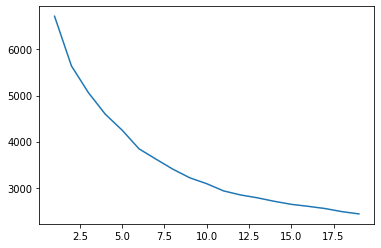

In [ ]:
plt.plot(range(1,20),err)

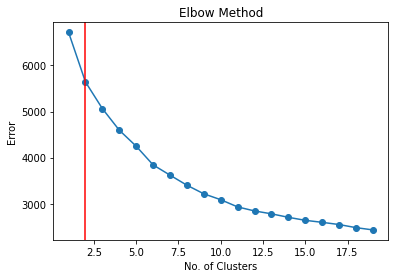

In [ ]:
plt.plot(range(1,20),err,marker='o')
plt.xlabel("No. of Clusters")
plt.ylabel("Error")
plt.title("Elbow Method")
plt.axvline(2,color="r")
plt.show()

In [ ]:
km1 = KMeans(n_clusters=2)
km1.fit(dfsc)

/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


KMeans(n_clusters=2)

In [ ]:
km1.labels_

array([0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,

In [ ]:
df['labels'] = km1.labels_
df.head()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,month_encoded,day_encoded,labels
0,7,5,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0,7,0,0
1,7,4,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0,10,5,1
2,7,4,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0,10,2,1
3,8,6,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0,7,0,0
4,8,6,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0,7,3,0


In [ ]:
df["labels"].value_counts()

1    397
0    120
Name: labels, dtype: int64

In [ ]:
from sklearn.metrics import silhouette_score

for i in range(2,10):
    km = KMeans(n_clusters=i)
    km.fit(dfsc)
    sil_score = silhouette_score(dfsc,km.labels_)
    print(sil_score)

/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


0.22324991841629335
0.1685841799536429


/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


0.1715520408454776
0.17726209802760748


/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


0.1807600564779291
0.17114112479711682


/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


0.18601465317148064
0.16553070639581574


/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


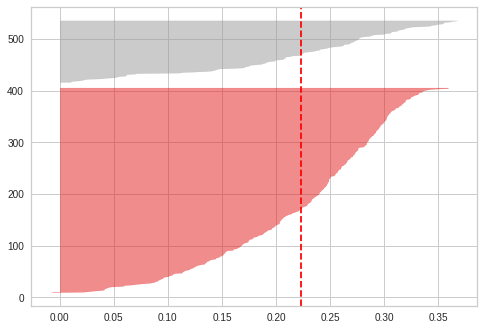

In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer

km5 = KMeans(n_clusters=2)
sil_vi = SilhouetteVisualizer(km5)
sil_vi.fit(dfsc)
plt.show()

/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


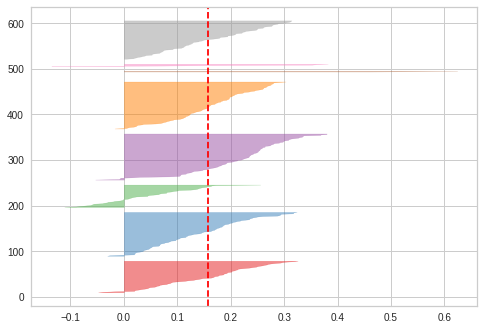

In [ ]:
km9 = KMeans(n_clusters=9)
sil_vi = SilhouetteVisualizer(km9)
sil_vi.fit(dfsc)
plt.show()

In [ ]:
df.to_csv("clustered.csv")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [ ]:
df

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,month_encoded,day_encoded,labels
0,7,5,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.00,7,0,0
1,7,4,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.00,10,5,1
2,7,4,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.00,10,2,1
3,8,6,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.00,7,0,0
4,8,6,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.00,7,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44,1,3,1
513,2,4,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29,1,3,0
514,7,4,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16,1,3,0
515,1,4,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00,1,2,1


In [ ]:
y = df['labels']

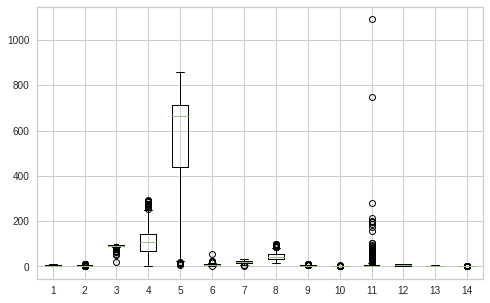

In [ ]:
import matplotlib.pyplot as plot 

_fig = plot.figure(figsize =(8, 5)) 
 
# Making a plot
plot.boxplot(df) 
 
# display the plot
plot.show()

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(df,y,test_size=0.2)

In [ ]:
lr = LinearRegression()
lr.fit(x_train,y_train)
pred = lr.predict(x_test)

In [ ]:
rmsenor = np.sqrt(metrics.mean_squared_error(y_test,pred))
rmsenor

9.174898621669079e-16

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(df)
scdf = sc.transform(df)
x_train,x_test,y_train,y_test = train_test_split(scdf,y,test_size=0.2)

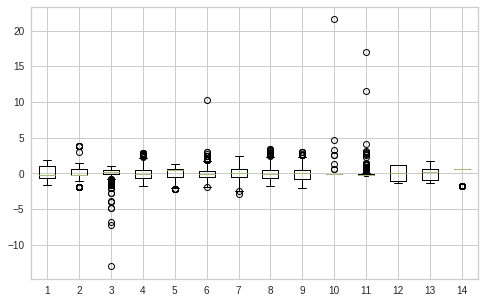

In [ ]:
import matplotlib.pyplot as plot 

 
_fig = plot.figure(figsize =(8, 5)) 
 
# Making a plot
plot.boxplot(scdf)


 
# display the plot
plot.show()

In [ ]:
lr = LinearRegression()
lr.fit(x_train,y_train)
pred = lr.predict(x_test)

In [ ]:
rmsestd = np.sqrt(metrics.mean_squared_error(y_test,pred))
rmsestd

6.303914829339916e-16

In [ ]:
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
mms.fit(df)
mmsdf = mms.transform(df)
x_train,x_test,y_train,y_test = train_test_split(mmsdf,y,test_size=0.2)

In [ ]:
lr = LinearRegression()
lr.fit(x_train,y_train)
pred = lr.predict(x_test)

In [ ]:
rmsemms = np.sqrt(metrics.mean_squared_error(y_test,pred))
rmsemms

2.9262529658290585e-16

In [ ]:
from sklearn.preprocessing import RobustScaler
rs = RobustScaler()
rs.fit(df)
rsdf = rs.transform(df)
x_train,x_test,y_train,y_test = train_test_split(rsdf,y,test_size=0.2)

In [ ]:
lr = LinearRegression()
lr.fit(x_train,y_train)
pred = lr.predict(x_test)

In [ ]:
rmserbs = np.sqrt(metrics.mean_squared_error(y_test,pred))
rmserbs

6.816979395120056e-16

In [ ]:
from sklearn.preprocessing import MaxAbsScaler
rss = MaxAbsScaler()
rss.fit(df)
rssdf = rss.transform(df)
x_train,x_test,y_train,y_test = train_test_split(rssdf,y,test_size=0.2)

In [ ]:
lr = LinearRegression()
lr.fit(x_train,y_train)
pred = lr.predict(x_test)

In [ ]:

rmsemas = np.sqrt(metrics.mean_squared_error(y_test,pred))
rmsemas

2.8075004588327475e-16

In [ ]:
from sklearn.preprocessing import QuantileTransformer
qt = QuantileTransformer()
qt.fit(df)
qtdf = qt.transform(df)
x_train,x_test,y_train,y_test = train_test_split(qtdf,y,test_size=0.2)

/usr/local/lib/python3.9/dist-packages/sklearn/preprocessing/_data.py:2627: UserWarning: n_quantiles (1000) is greater than the total number of samples (517). n_quantiles is set to n_samples.
  warnings.warn(


In [ ]:
lr = LinearRegression()
lr.fit(x_train,y_train)
pred = lr.predict(x_test)

In [ ]:
rmseqts = np.sqrt(metrics.mean_squared_error(y_test,pred))
rmseqts

4.680439015762917e-16

In [ ]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method = 'yeo-johnson')
'''
parameters:
method = 'box-cox' or 'yeo-johnson'
'''
pt.fit(df)
ptdf = qt.transform(df)
x_train,x_test,y_train,y_test = train_test_split(ptdf,y,test_size=0.2)

In [ ]:
lr = LinearRegression()
lr.fit(x_train,y_train)
pred = lr.predict(x_test)

In [ ]:
rmsepts = np.sqrt(metrics.mean_squared_error(y_test,pred))
rmsepts

4.066311571270223e-16

In [ ]:
from sklearn.preprocessing import Normalizer
ns = Normalizer(norm = 'l2')
# norm = 'l2' is default
ns.fit(df)
nsdf = ns.transform(df)
x_train,x_test,y_train,y_test = train_test_split(nsdf,y,test_size=0.2)

In [ ]:
lr = LinearRegression()
lr.fit(x_train,y_train)
pred = lr.predict(x_test)

In [ ]:
rmsenorm = np.sqrt(metrics.mean_squared_error(y_test,pred))
rmsenorm

0.10900805434847621

In [ ]:
#The distribution of rain and area variables is too skewed and has outliers, then scaling will be done on both variables.
print(len(nsdf))
print(nsdf.shape)
# print(nsdf[:,[1,2]])

df3 = pd.DataFrame(nsdf[:,[3,4]],columns=['rain','area'])

print(df. columns)

517
(517, 14)
Index(['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain',
       'area', 'month_encoded', 'day_encoded', 'labels'],
      dtype='object')


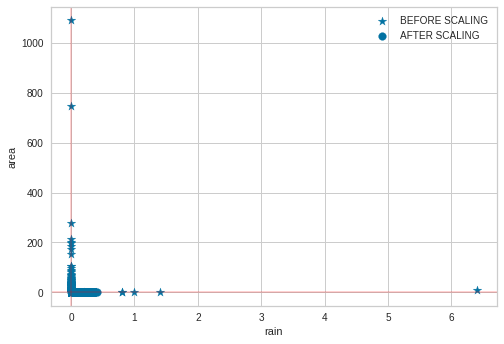

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

ax = df.plot.scatter(x='rain', y='area',marker = '*',s=80, label='BEFORE SCALING')
df3.plot.scatter(x='rain', y='area', marker = 'o',s=60,label='AFTER SCALING', ax = ax)
plt.axhline(0, color='red',alpha=0.2)
plt.axvline(0, color='red',alpha=0.2)

In [ ]:
def valuelabel(x,y):
    for i in range(len(x)):
        plt.text(i,y[i],y[i], ha = 'center',
                 bbox = dict(facecolor = 'cyan', alpha =0.8))

/usr/local/lib/python3.9/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


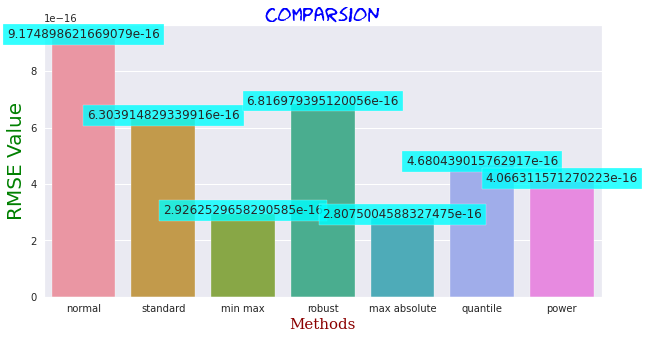

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')

x = ['normal', 'standard', 'min max', 'robust', 'max absolute', 'quantile', 'power']
y = [rmsenor, rmsestd, rmsemms, rmserbs, rmsemas, rmseqts, rmsepts]

fig = plot.figure()

fig.set_figheight(5)
fig.set_figwidth(10)

sns.barplot(x, y)

font1 = {'family':'fantasy','color':'blue','size':20}
font2 = {'family':'serif','color':'darkred','size':15}
font3 = {'family':'cursive','color':'green','size':20}

 # Call function
valuelabel(x, y) 

plt.title("Comparsion", fontdict = font1)
plt.xlabel("Methods", fontdict = font2)
plt.ylabel("RMSE Value", fontdict = font3)

plt.show()

In [ ]:
print(df)

     X  Y  FFMC    DMC     DC   ISI  temp  RH  wind  rain   area  \
0    7  5  86.2   26.2   94.3   5.1   8.2  51   6.7   0.0   0.00   
1    7  4  90.6   35.4  669.1   6.7  18.0  33   0.9   0.0   0.00   
2    7  4  90.6   43.7  686.9   6.7  14.6  33   1.3   0.0   0.00   
3    8  6  91.7   33.3   77.5   9.0   8.3  97   4.0   0.2   0.00   
4    8  6  89.3   51.3  102.2   9.6  11.4  99   1.8   0.0   0.00   
..  .. ..   ...    ...    ...   ...   ...  ..   ...   ...    ...   
512  4  3  81.6   56.7  665.6   1.9  27.8  32   2.7   0.0   6.44   
513  2  4  81.6   56.7  665.6   1.9  21.9  71   5.8   0.0  54.29   
514  7  4  81.6   56.7  665.6   1.9  21.2  70   6.7   0.0  11.16   
515  1  4  94.4  146.0  614.7  11.3  25.6  42   4.0   0.0   0.00   
516  6  3  79.5    3.0  106.7   1.1  11.8  31   4.5   0.0   0.00   

     month_encoded  day_encoded  labels  
0                7            0       0  
1               10            5       1  
2               10            2       1  
3              

In [ ]:
print(mmsdf)

[[0.75       0.42857143 0.87096774 ... 0.63636364 0.         0.        ]
 [0.75       0.28571429 0.92774194 ... 0.90909091 0.83333333 1.        ]
 [0.75       0.28571429 0.92774194 ... 0.90909091 0.33333333 1.        ]
 ...
 [0.75       0.28571429 0.8116129  ... 0.09090909 0.5        0.        ]
 [0.         0.28571429 0.97677419 ... 0.09090909 0.33333333 1.        ]
 [0.625      0.14285714 0.78451613 ... 0.81818182 0.83333333 0.        ]]
